In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from plotnine import *

In [3]:
custom_colors = [
    "#1D2951",  # Space Cadet (dark blue)
    "#FFD166",  # Warm Yellow
    "#4BA3C3",  # Sky Blue
    "#F25C54",  # Coral Red
    "#007C91",  # Deep Teal
    "#EF798A",  # Dusty Rose
    "#6DCDB8",  # Mint Green
    "#FF9F1C",  # Vivid Orange
    "#6B4C9A",  # Violet Indigo
    "#A4C400",  # Lime Green
    "#8E7DBE",  # Lavender Purple
    "#2E8B57",  # Sea Green
]

In [4]:
# Bug causes the problem that automatic coloring does not work anymore
# -> Create custom color palette

# Add large qualitative colormaps together
colors = (
    plt.cm.Paired.colors
    + plt.cm.Set1.colors
    + plt.cm.tab20.colors
    + plt.cm.Set2.colors
    + plt.cm.tab20b.colors
    + plt.cm.Set3.colors
    + plt.cm.tab20c.colors
)

custom_colors_xl = [plt.matplotlib.colors.to_hex(c) for c in colors]
custom_colors_xl = custom_colors + custom_colors_xl

len(custom_colors_xl)

113

In [5]:
figure_theme = theme_minimal() + theme(
    plot_background=element_rect(fill="#ffffff", color="#ffffff"),
    plot_tag=element_text(face="bold"),
    axis_title=element_text(size=10, face="plain"),
    axis_text=element_text(size=9, face="plain"),
    text=element_text(family="DejaVu Sans"),
    legend_title=element_blank(),
)

## Cell Type Distribution (scRNA-seq Data)

In [5]:
cell_types = pd.read_feather("data/pdata_cell_types.feather")

# Rename column to make it more readable
cell_types["annotation"] = cell_types["annotation"].replace(
    {"Monocytes & Monocyte-derived cells": "Monocytes &\nMonocyte-derived cells"}
)
cell_types.head()

,Dataset,annotation,count,percentage
0,Healthy,Endothelial cells,50194,27.001409
1,Healthy,Kupffer cells,39311,21.146998
2,Healthy,Hepatocytes,25908,13.936975
3,Healthy,Monocytes &\nMonocyte-derived cells,20712,11.141834
4,Healthy,T cells,9912,5.332071


/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/train_cell_types.svg


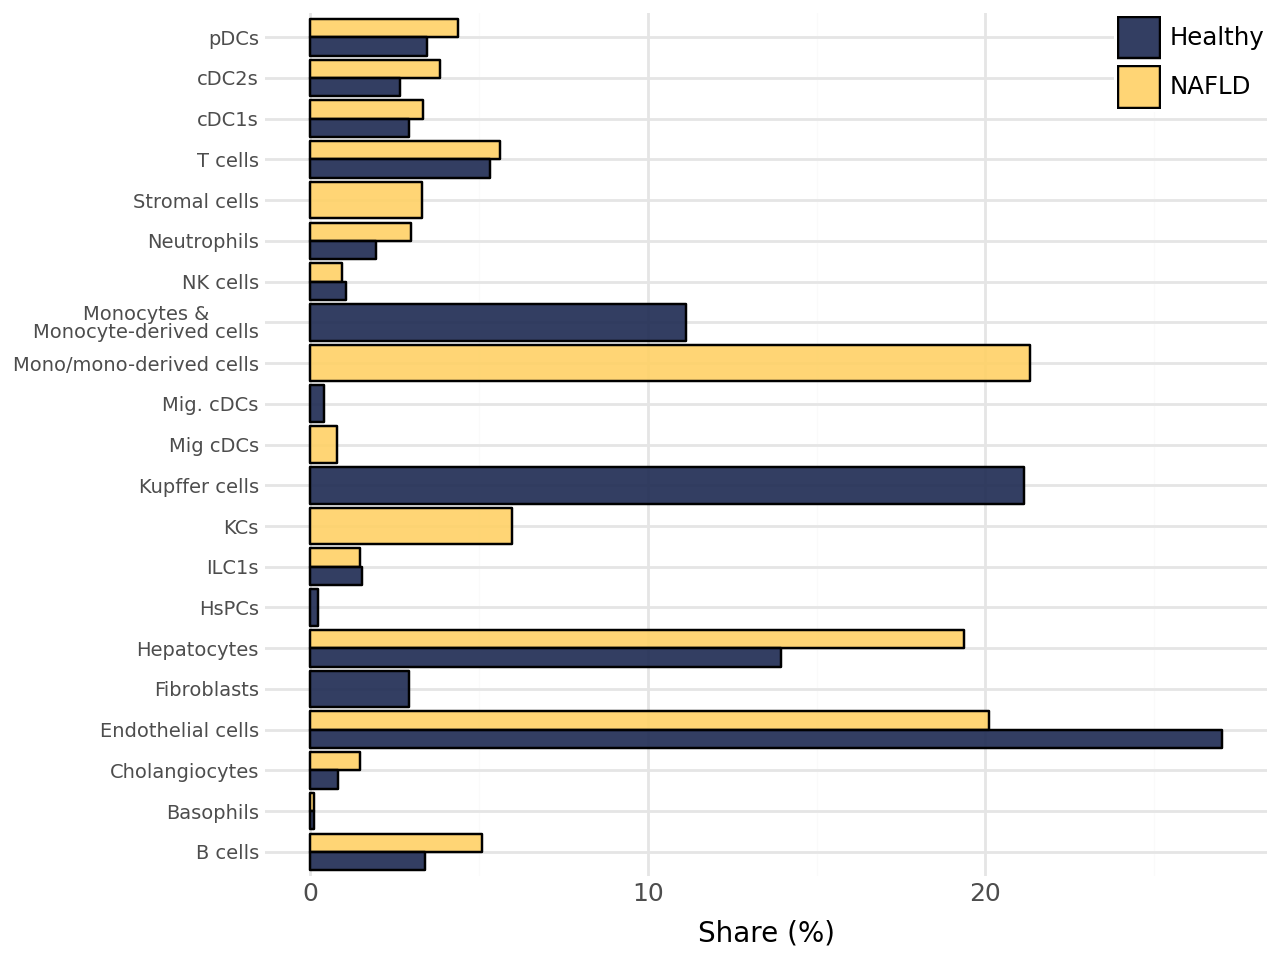

In [10]:
plot = (
    ggplot(cell_types, aes(x="annotation", y="percentage", fill="Dataset"))
    + geom_col(position="dodge", alpha=0.9, color="black")
    + coord_flip()
    + scale_fill_manual(values=["#1D2951", "#FFD166"])
    + labs(x="", y="Share (%)")
    + figure_theme
    + theme(
        legend_title=element_blank(),
        legend_position=(1, 1),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
        axis_text_y=element_text(size=7),
    )
)

plot.save("output/train_cell_types.svg", dpi=300)
plot

## Cells per Field of View

In [37]:
# Load data
data = pd.read_feather("data/pdata_cells_per_fov.feather")
data.head()

,group,dataset,value
0,10,liver1,705
1,10,liver2,897
2,11,liver1,787
3,11,liver2,669
4,12,liver1,925


In [38]:
# Preprocess data
data["dataset"] = data["dataset"].replace({"liver1": "Liver1", "liver2": "Liver2"})

# Order groups by descending order
data["group"] = data["group"].astype(int)
data["group"] = pd.Categorical(
    data["group"], categories=sorted(data["group"].unique(), reverse=True), ordered=True
)

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/#cells_per_fov.svg


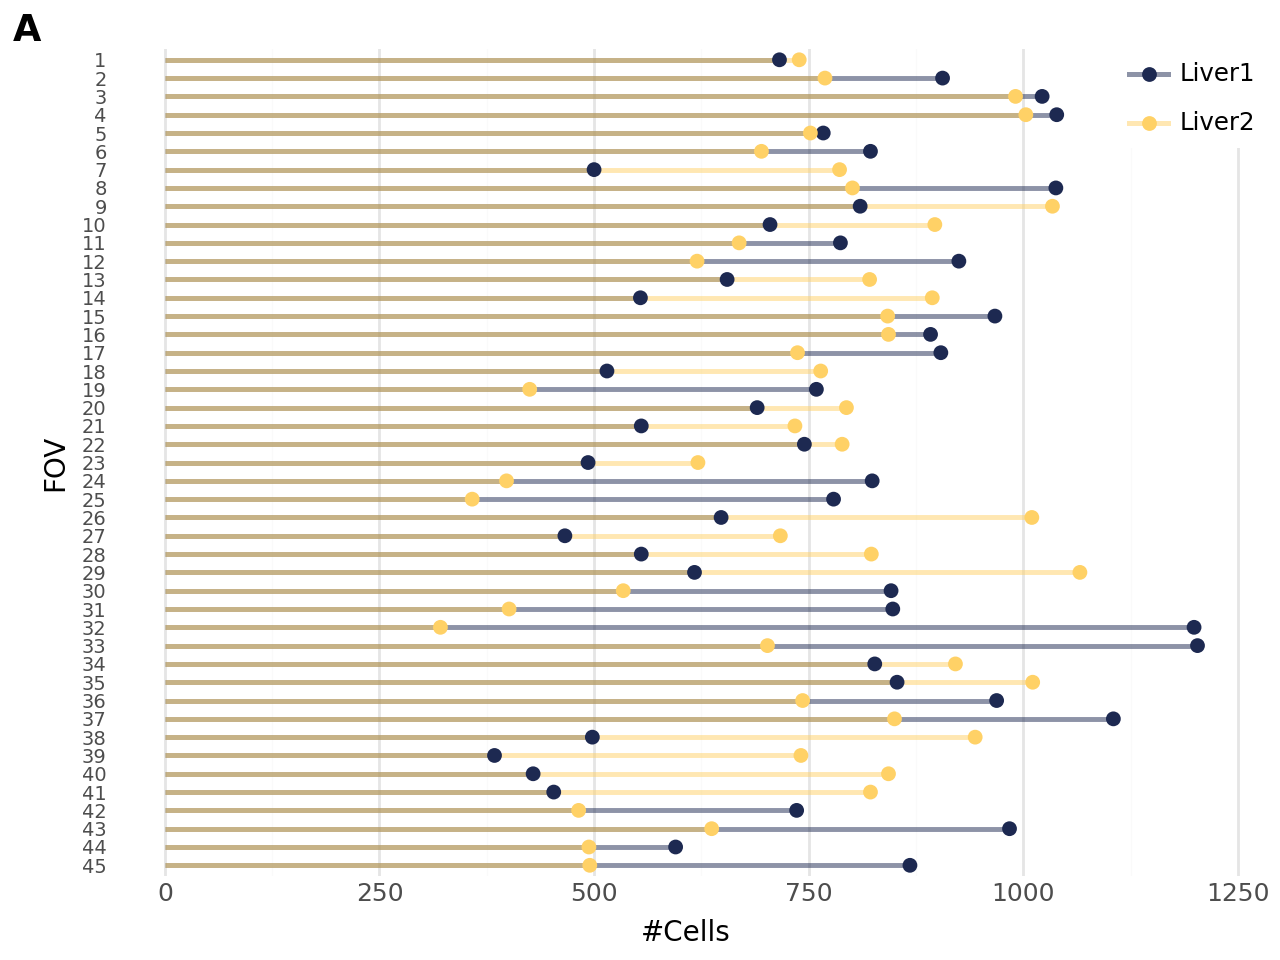

In [39]:
plot = (
    ggplot(data, aes(y="group", x="value", color="dataset"))
    + geom_segment(aes(x=0, xend="value", y="group", yend="group"), size=1, alpha=0.5)
    + geom_point(size=2)
    + scale_x_continuous(limits=(0, data["value"].max() + 10))
    + scale_y_discrete()
    + scale_color_manual(values=custom_colors[:2])
    + labs(tag="A", x="#Cells", y="FOV")
    + figure_theme
    + theme(
        panel_grid_major_y=element_blank(),
        legend_position=(1, 1),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
        axis_text_y=element_text(size=7),
    )
)

plot.save("output/parts/#cells_per_fov.svg", dpi=300)
plot

## Count Distributions (Spatial Transcriptomics Data)

In [16]:
# Load cell count distribution
data = pd.read_feather("data/pdata_counts_per_cell.feather")

data["dataset"] = data["dataset"].replace({"liver1": "Liver1", "liver2": "Liver2"})
data["disease_state"] = data["disease_state"].map(
    {
        "healthy": "Healthy",
        "steatosis": "Steatosis",
        "cirrhosis": "Cirrhosis",
        "aclf": "ACLF",
    }
)

data.head()

,value,dataset,disease_state
0,450.0,Liver1,Healthy
1,780.0,Liver1,Healthy
2,752.0,Liver1,Healthy
3,725.0,Liver1,Healthy
4,395.0,Liver1,Healthy


/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/density_sample_counts.svg


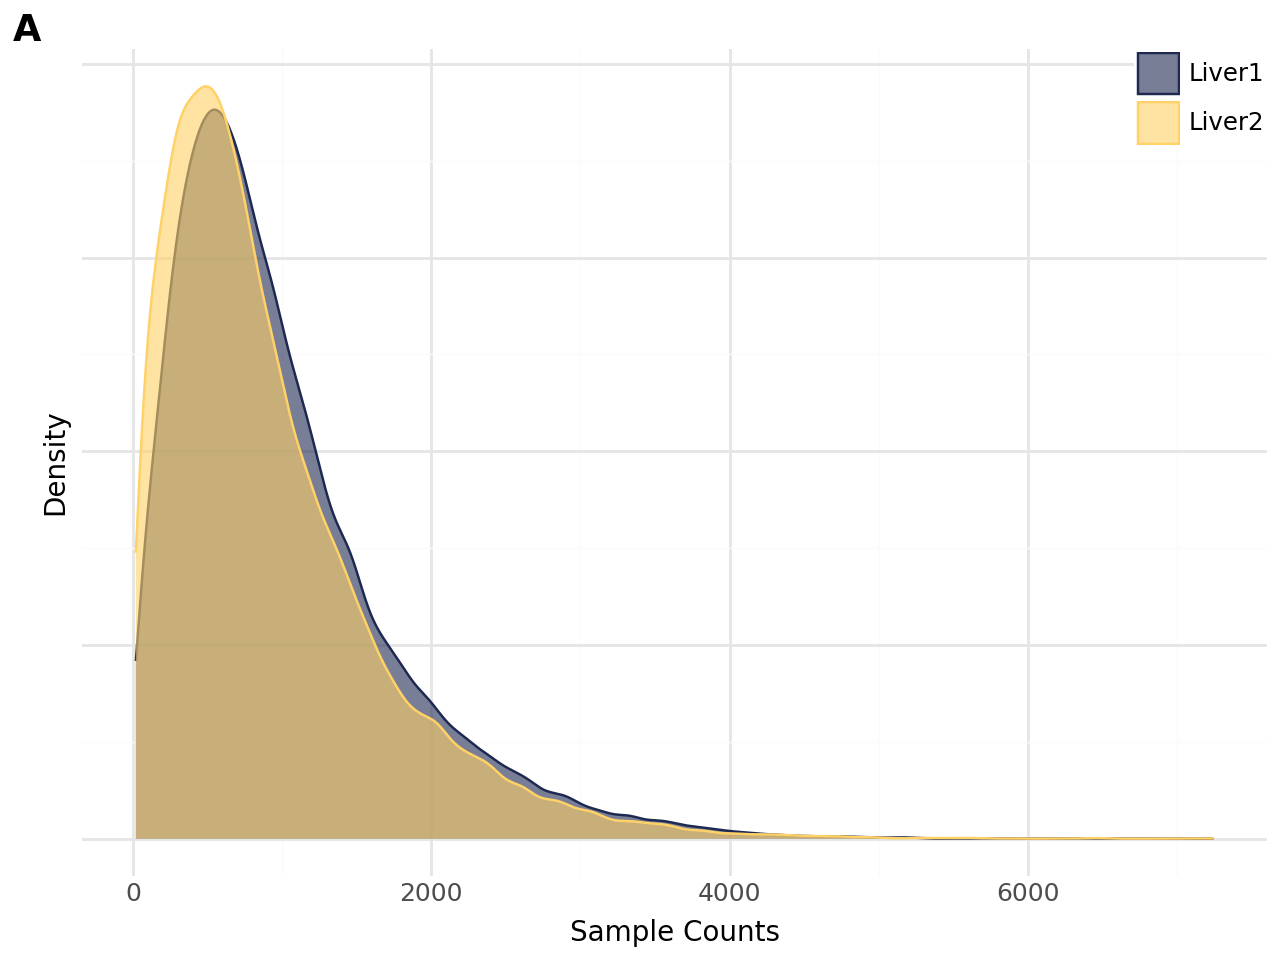

In [17]:
plot = (
    ggplot(data, aes(x="value", color="dataset", fill="dataset"))
    + geom_density(alpha=0.6)
    + scale_color_manual(custom_colors[:2])
    + scale_fill_manual(custom_colors[:2])
    + labs(tag="A", x="Sample Counts", y="Density")
    + figure_theme
    + theme(
        axis_text_y=element_blank(),
        legend_position=(1, 1),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/density_sample_counts.svg", dpi=300)
plot

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/ecdf_sample_counts.svg


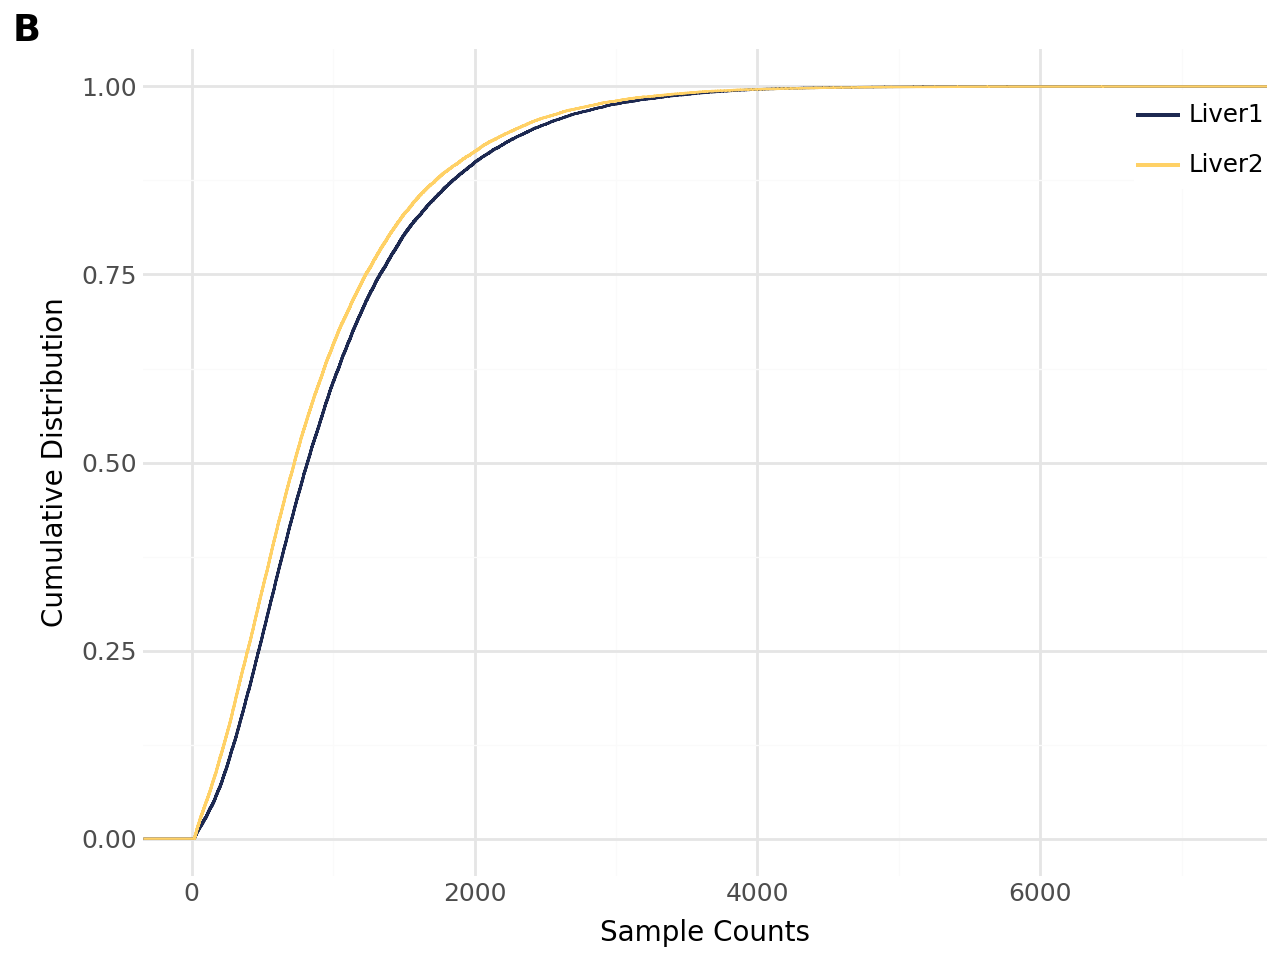

In [18]:
plot = (
    ggplot(data, aes(x="value", color="dataset"))
    + stat_ecdf(geom="step")
    + scale_color_manual(custom_colors[:2])
    + labs(
        tag="B",
        x="Sample Counts",
        y="Cumulative Distribution",
    )
    + figure_theme
    + theme(
        legend_position=(1, 0.95),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/ecdf_sample_counts.svg", dpi=300)
plot

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/density_condition_counts.svg


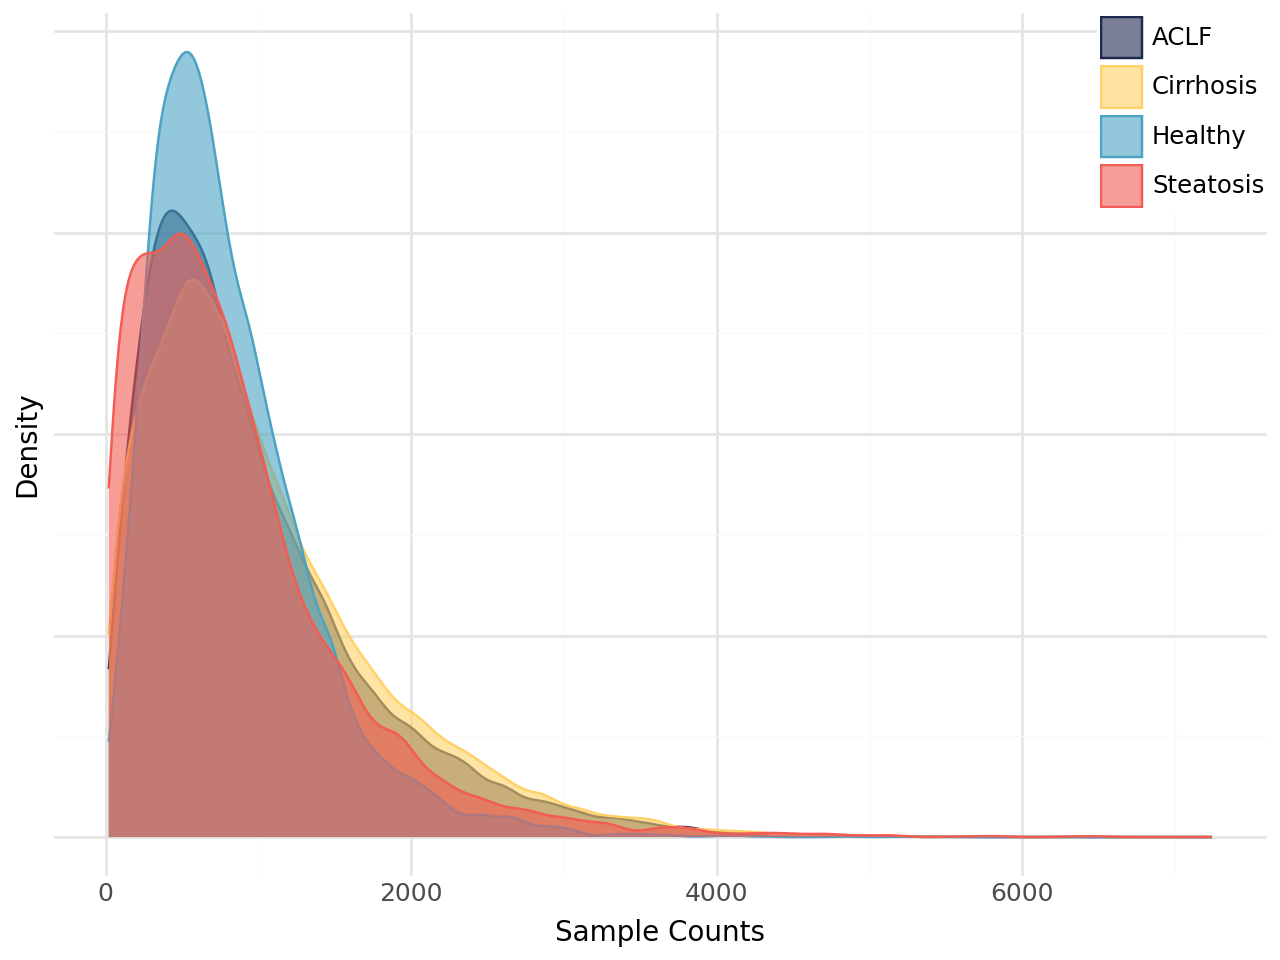

In [19]:
plot = (
    ggplot(data, aes(x="value", color="disease_state", fill="disease_state"))
    + geom_density(alpha=0.6)
    + scale_color_manual(custom_colors[:4])
    + scale_fill_manual(custom_colors[:4])
    + labs(
        x="Sample Counts",
        y="Density",
        color="Condition",
        fill="Condition",
    )
    + figure_theme
    + theme(
        legend_position=(1, 1),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
        axis_text_y=element_blank(),
    )
)

plot.save("output/parts/density_condition_counts.svg", dpi=300)
plot

In [20]:
# Load gene count distribution
data = pd.read_feather("data/pdata_counts_per_gene.feather")

data = data.rename(columns={"value": "log10p1"})
data["dataset"] = data["dataset"].replace({"liver1": "Liver1", "liver2": "Liver2"})

data.head()

,raw_counts,dataset,log10p1
0,9926.0,Liver1,3.996818
1,23954.0,Liver1,4.379396
2,4548.0,Liver1,3.657916
3,8327.0,Liver1,3.920541
4,2801.0,Liver1,3.447468


/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/density_gene_counts.svg


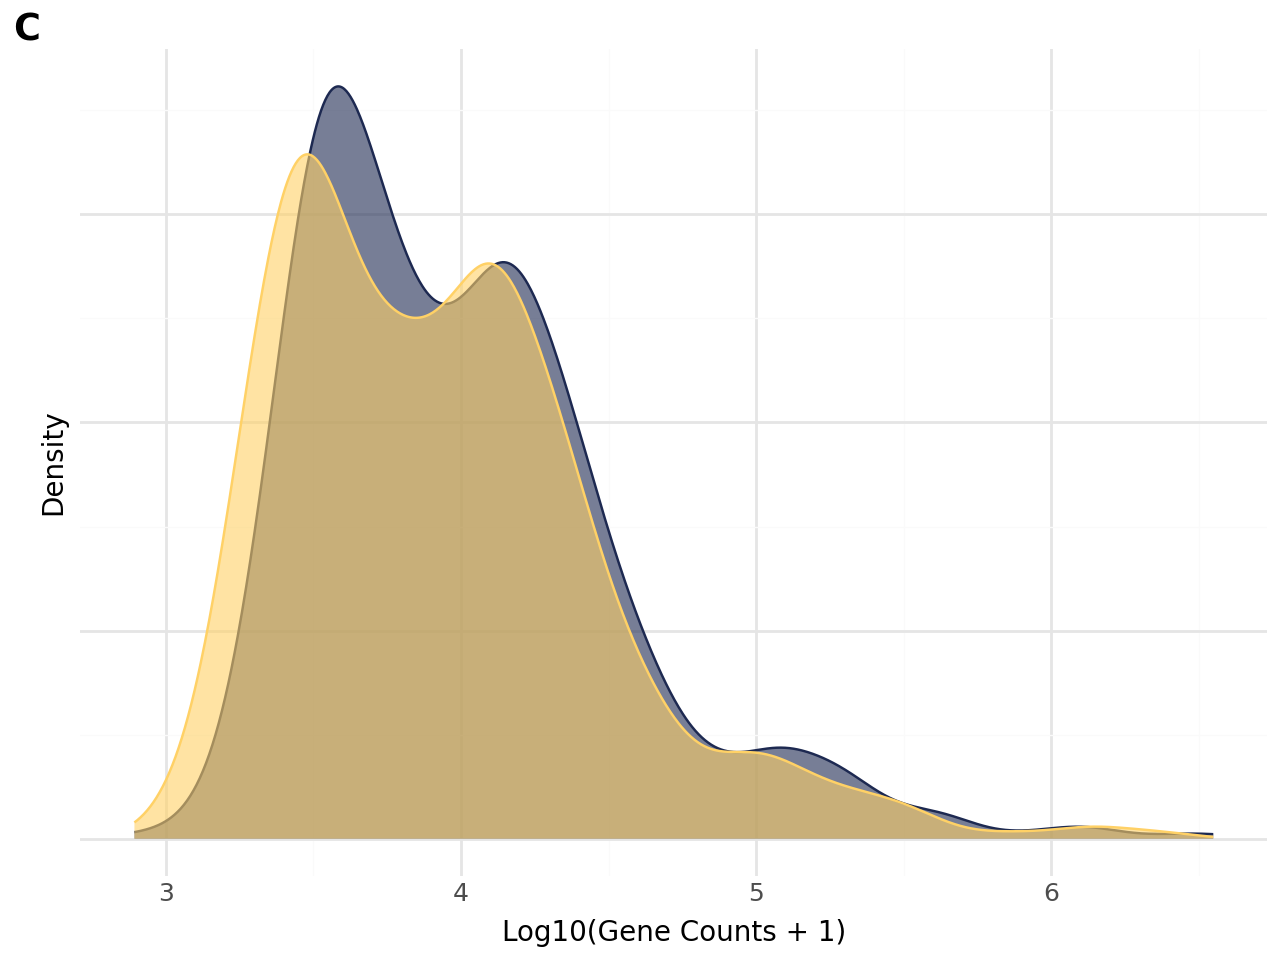

In [21]:
plot = (
    ggplot(data, aes(x="log10p1", color="dataset", fill="dataset"))
    + geom_density(alpha=0.6)
    + scale_color_manual(custom_colors[:2])
    + scale_fill_manual(custom_colors[:2])
    + labs(
        tag="C",
        x="Log10(Gene Counts + 1)",
        y="Density",
        color="Dataset",
        fill="Dataset",
    )
    + guides(fill="none", color="none")
    + figure_theme
    + theme(
        axis_text_y=element_blank(),
    )
)

plot.save("output/parts/density_gene_counts.svg", dpi=300)
plot

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/ecdf_gene_counts.svg


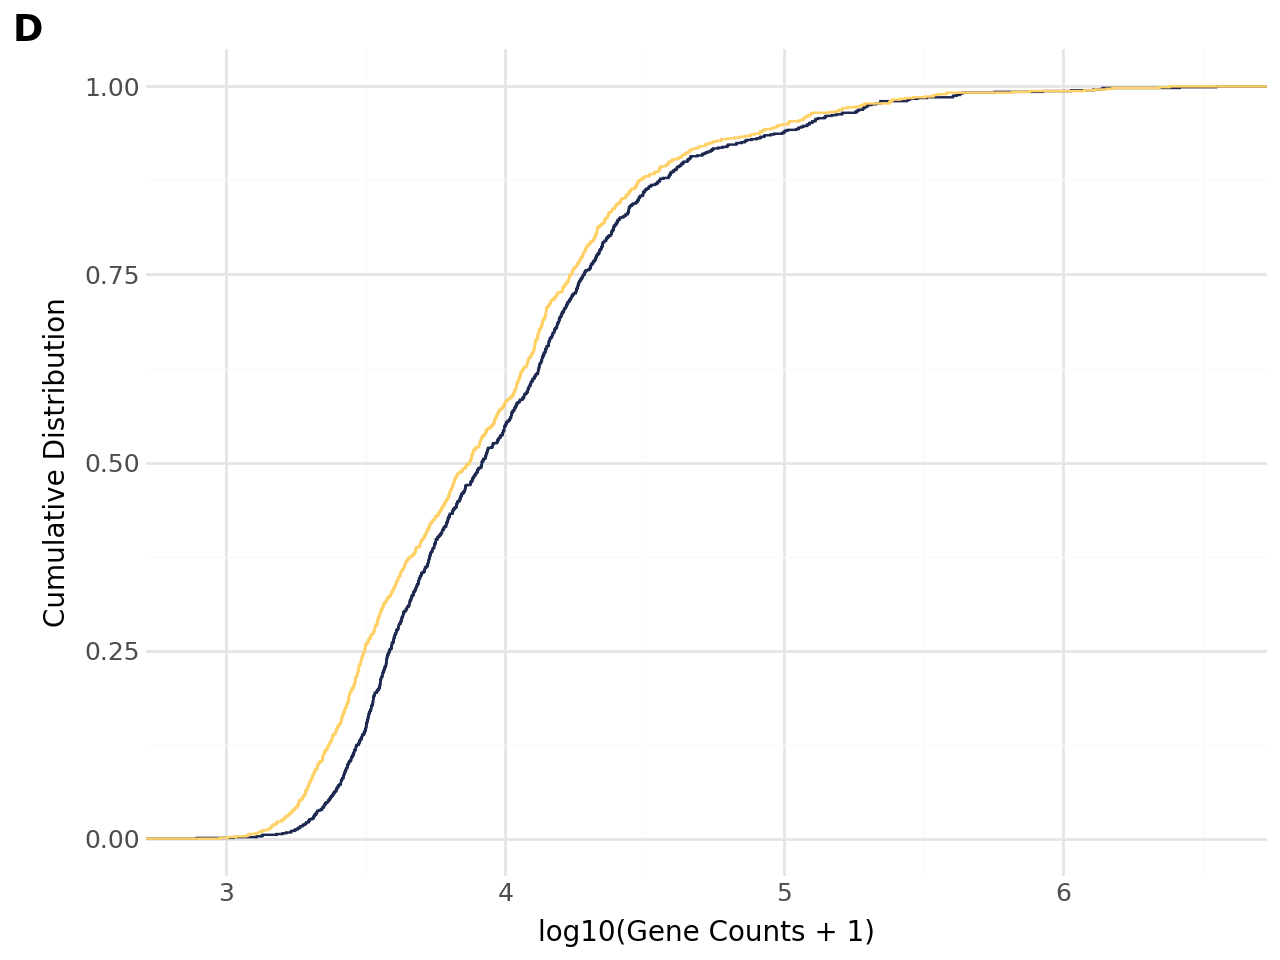

In [24]:
plot = (
    ggplot(data, aes(x="log10p1", color="dataset"))
    + stat_ecdf(geom="step")
    + scale_color_manual(custom_colors[:2])
    + labs(tag="D", x="log10(Gene Counts + 1)", y="Cumulative Distribution")
    + guides(color="none")
    + figure_theme
)

plot.save("output/parts/ecdf_gene_counts.svg", dpi=300)
plot

## Count Distributions (Combined Data)

In [25]:
train_sample_counts = pd.read_feather("data/pdata_train_sample_counts.feather")
train_sample_counts = train_sample_counts.rename(
    columns={"Dataset": "dataset", "counts": "value"}
)
train_sample_counts.head()

,value,dataset
AAACCTGAGAGCCCAA-1,2293,Healthy
AAACCTGAGCTAGTCT-1,2066,Healthy
AAACCTGAGTTCGCGC-1,1013,Healthy
AAACCTGCAACACCCG-1,2209,Healthy
AAACCTGCATAGGATA-1,5290,Healthy


In [26]:
st_sample_counts = pd.read_feather("data/pdata_counts_per_cell.feather")

st_sample_counts = st_sample_counts[["value", "dataset"]]
st_sample_counts["dataset"] = st_sample_counts["dataset"].replace(
    {
        "liver1": "Liver1",
        "liver2": "Liver2",
    }
)

st_sample_counts.head()

,value,dataset
0,450.0,Liver1
1,780.0,Liver1
2,752.0,Liver1
3,725.0,Liver1
4,395.0,Liver1


In [27]:
data = pd.concat([st_sample_counts, train_sample_counts], ignore_index=True)

data["dataset"] = pd.Categorical(
    data["dataset"],
    categories=[
        "Liver1",
        "Liver2",
        "Healthy",
        "NAFLD",
    ],
    ordered=True,
)

data.dataset.unique()

['Liver1', 'Liver2', 'Healthy', 'NAFLD']
Categories (4, object): ['Liver1' < 'Liver2' < 'Healthy' < 'NAFLD']

In [28]:
data["z_scores"] = data.groupby("dataset", observed=True)["value"].transform(
    lambda x: (x - x.mean()) / x.std()
)
data.head()

,value,dataset,z_scores
0,450.0,Liver1,-0.743173
1,780.0,Liver1,-0.300586
2,752.0,Liver1,-0.338138
3,725.0,Liver1,-0.374350
4,395.0,Liver1,-0.816938


In [ ]:
plot = (
    ggplot(data, aes(x="dataset", y="z_scores", fill="dataset"))
    + geom_violin(position="dodge", alpha=0.9)
    + geom_boxplot(width=0.1, fill="#ffffff")
    + scale_fill_manual(values=custom_colors[:4])
    + labs(tag="A", x="", y="z-score(Sample Counts)")
    + figure_theme
    + theme(
        legend_position=(1, 1),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/violin_sample_counts_all.png", dpi=300)
plot

In [8]:
train_gene_counts = pd.read_feather("data/pdata_train_gene_counts.feather")

train_gene_counts = train_gene_counts.rename(
    columns={
        "Dataset": "dataset",
        "counts": "value",
    }
)

train_gene_counts.head()

,value,dataset
Xkr4,3.368101,Healthy
Gm1992,1.342423,Healthy
Gm37381,1.113943,Healthy
Rp1,2.431364,Healthy
Sox17,4.504158,Healthy


In [11]:
# Load gene count distribution
st_gene_counts = pd.read_feather("data/pdata_counts_per_gene.feather")

st_gene_counts = st_gene_counts[["dataset", "value"]]
st_gene_counts["dataset"] = st_gene_counts["dataset"].replace(
    {
        "liver1": "Liver1",
        "liver2": "Liver2",
    }
)


st_gene_counts.head()

,dataset,value
0,Liver1,3.996818
1,Liver1,4.379396
2,Liver1,3.657916
3,Liver1,3.920541
4,Liver1,3.447468


In [13]:
data = pd.concat([st_gene_counts, train_gene_counts], ignore_index=True)

data["dataset"] = pd.Categorical(
    data["dataset"],
    categories=[
        "Liver1",
        "Liver2",
        "Healthy",
        "NAFLD",
    ],
    ordered=True,
)

data.dataset.unique()

['Liver1', 'Liver2', 'Healthy', 'NAFLD']
Categories (4, object): ['Liver1' < 'Liver2' < 'Healthy' < 'NAFLD']

In [ ]:
plot = (
    ggplot(data, aes(x="dataset", y="value", fill="dataset"))
    + geom_violin(position="dodge", alpha=0.9, raster=True)
    + geom_boxplot(width=0.1, fill="#ffffff")
    + scale_fill_manual(values=custom_colors[:4])
    + labs(tag="C", x="", y="log10(Gene Counts +1)")
    + guides(fill="none")
    + figure_theme
)

plot.save("output/parts/violin_gene_counts_all.svg", dpi=300)
plot

## Sparsity (scRNA-seq Data)

In [29]:
train_sample_sparsity = pd.read_feather("data/pdata_train_sample_sparsity.feather")
train_sample_sparsity.head()

,Dataset,sparsity_range,count,percentage
0,Healthy,<50%,0,0.000000
1,Healthy,50-80%,339,0.182362
2,Healthy,80-90%,27159,14.609939
3,Healthy,90-95%,93123,50.094678
4,Healthy,95-99%,65232,35.090966


/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/train_sample_sparsity.svg


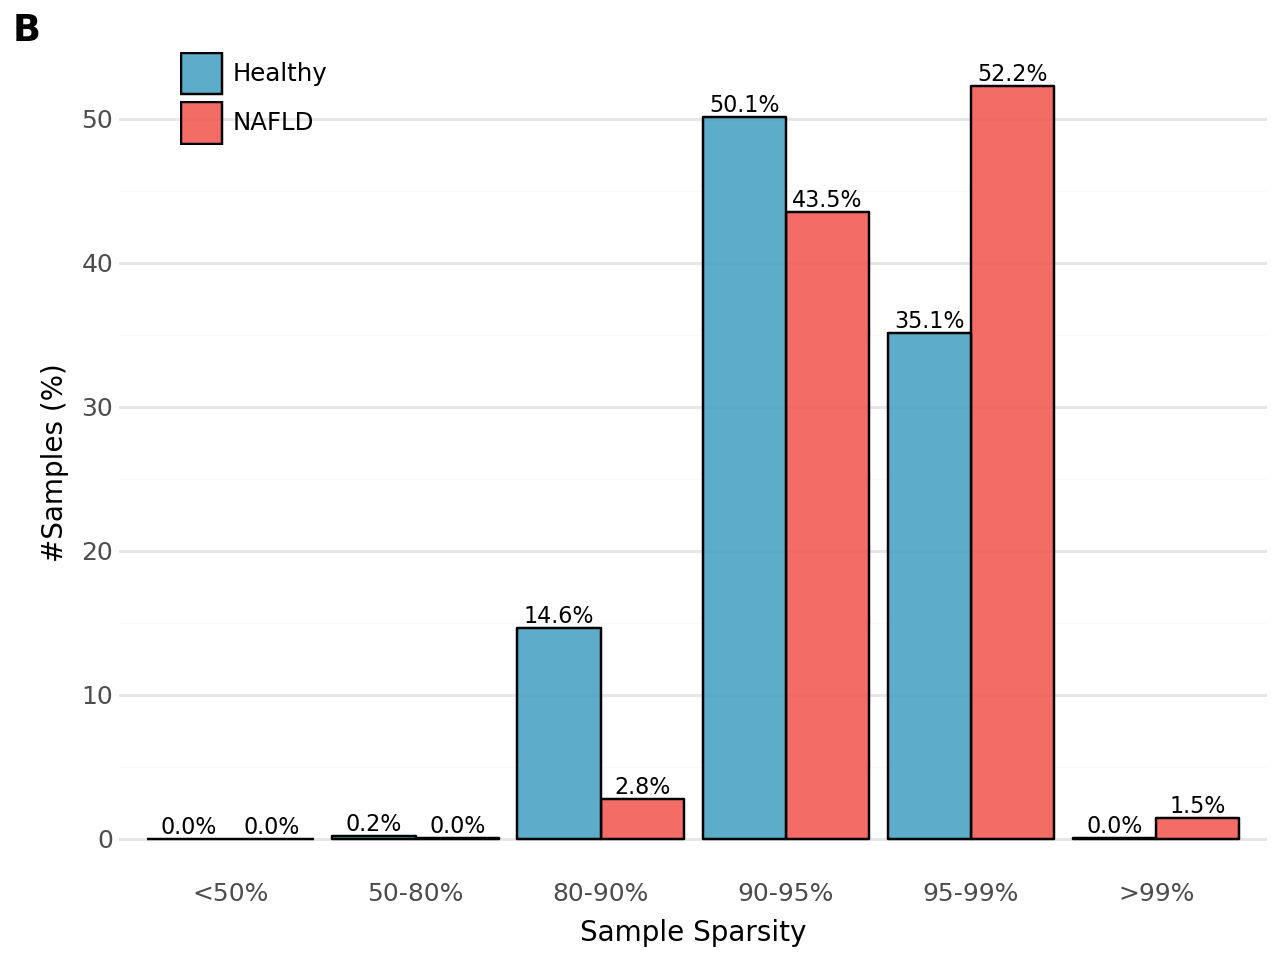

In [50]:
plot = (
    ggplot(
        train_sample_sparsity, aes(x="sparsity_range", y="percentage", fill="Dataset")
    )
    + geom_col(position="dodge", alpha=0.9, color="#000000")
    + geom_text(
        aes(label="percentage"),
        format_string="{:.1f}%",
        position=position_dodge(width=0.9),
        va="bottom",
        size=8,
    )
    + scale_fill_manual(values=custom_colors[2:4])
    + labs(tag="B", x="Sample Sparsity", y="#Samples (%)")
    + figure_theme
    + theme(
        panel_grid_major_x=element_blank(),
        legend_position=(0.05, 1),
        legend_justification=(0, 1),
    )
)

plot.save("output/parts/train_sample_sparsity.svg", dpi=300)
plot

In [41]:
train_gene_sparsity = pd.read_feather("data/pdata_train_gene_sparsity.feather")
train_gene_sparsity.head()

,Dataset,sparsity_range,count,percentage
0,Healthy,<50%,548,1.764725
1,Healthy,50-80%,3094,9.963611
2,Healthy,80-90%,3350,10.788008
3,Healthy,90-95%,2513,8.092616
4,Healthy,95-99%,3146,10.131066


/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/train_gene_sparsity.svg


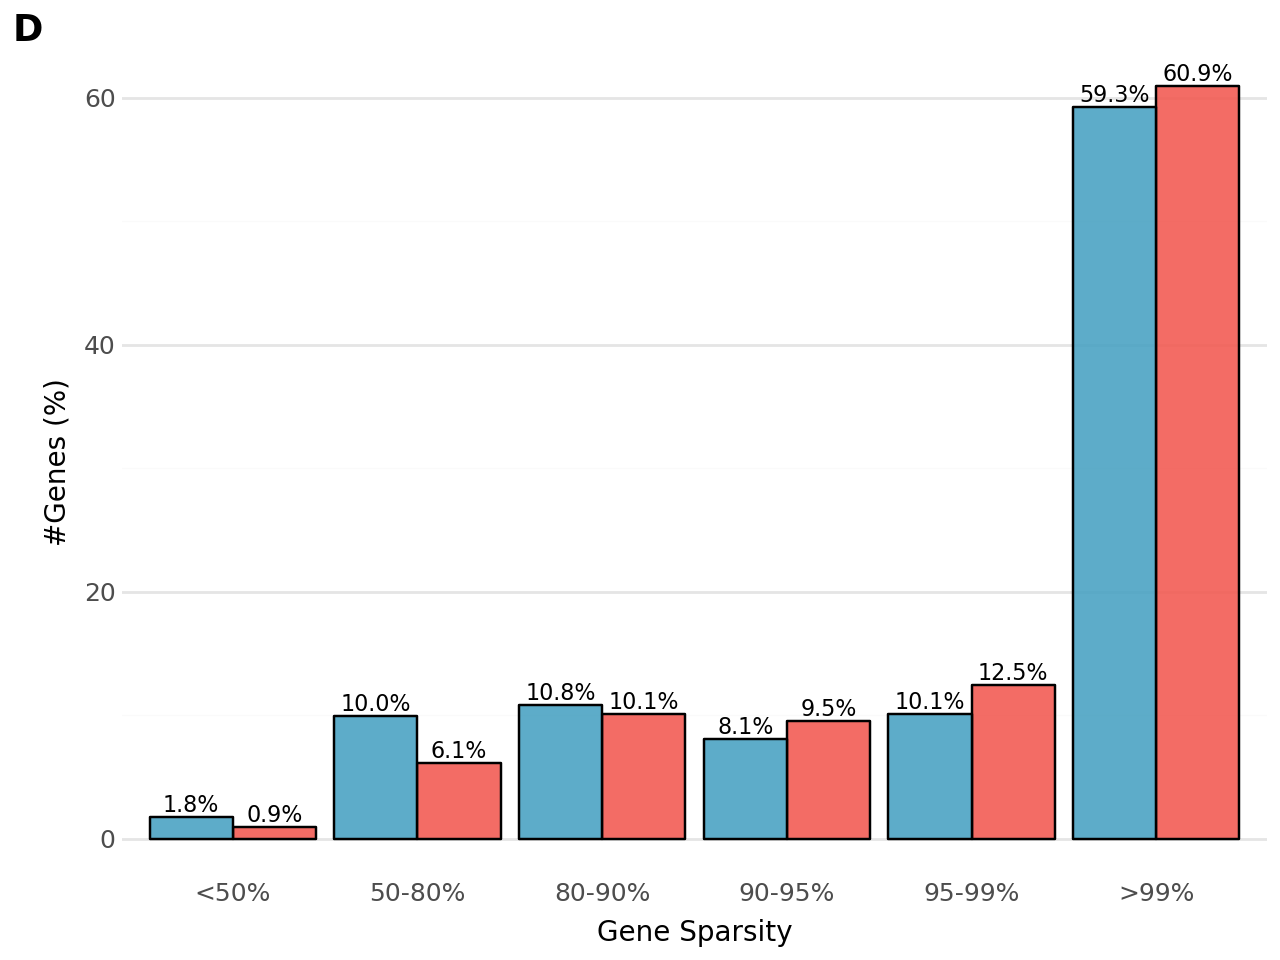

In [49]:
plot = (
    ggplot(train_gene_sparsity, aes(x="sparsity_range", y="percentage", fill="Dataset"))
    + geom_col(position="dodge", alpha=0.9, color="#000000")
    + geom_text(
        aes(label="percentage"),
        format_string="{:.1f}%",
        position=position_dodge(width=0.9),
        va="bottom",
        size=8,
    )
    + scale_fill_manual(values=custom_colors[2:4])
    + labs(tag="D", x="Gene Sparsity", y="#Genes (%)")
    + guides(fill="none")
    + figure_theme
    + theme(
        panel_grid_major_x=element_blank(),
    )
)

plot.save("output/parts/train_gene_sparsity.svg", dpi=300)
plot

## UMAPs Before Integration

In [47]:
# Add original cell types to plot data
ct_anno = pd.read_feather("data/pdata_original_cell_types.feather")
ct_anno = ct_anno.set_index("id")["nb_clus"]
ct_anno

id
liver1_3_1       Pericentral.hepatocyte
liver1_4_1                            a
liver1_5_1       Pericentral.hepatocyte
liver1_7_1                 Stromal.cell
liver1_8_1                            a
                          ...          
liver2_531_45    Pericentral.hepatocyte
liver2_532_45                         d
liver2_533_45    Pericentral.hepatocyte
liver2_534_45                         d
liver2_535_45                         d
Name: nb_clus, Length: 67785, dtype: object

In [48]:
data = pd.read_feather("data/pdata_umaps_ST.feather")

data["original_ct"] = ct_anno
data["fov"] = pd.Categorical(data["fov"])
data["condition"] = data["condition"].map(
    {
        "healthy": "Healthy",
        "steatosis": "Steatosis",
        "cirrhosis": "Cirrhosis",
        "aclf": "ACLF",
    }
)

data

,slide,fov,condition,umap_1,umap_2,original_ct
liver1_3_1,S2,1_liver1,Healthy,0.167600,8.806798,Pericentral.hepatocyte
liver1_4_1,S2,1_liver1,Healthy,-0.847367,6.216402,a
liver1_5_1,S2,1_liver1,Healthy,0.175900,6.586068,Pericentral.hepatocyte
liver1_7_1,S2,1_liver1,Healthy,2.945525,9.352727,Stromal.cell
liver1_8_1,S2,1_liver1,Healthy,-0.567749,9.055143,a
...,...,...,...,...,...,...
liver2_531_45,S3,45_liver2,Cirrhosis,0.605701,7.784894,Pericentral.hepatocyte
liver2_532_45,S3,45_liver2,Cirrhosis,-2.704872,4.453344,d
liver2_533_45,S3,45_liver2,Cirrhosis,1.871059,6.471807,Pericentral.hepatocyte
liver2_534_45,S3,45_liver2,Cirrhosis,-1.875127,1.386655,d


In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="slide"))
    + geom_point(
        alpha=0.8,
        size=1,
        stroke=0,
        raster=True,  # Raster to decrease figure size
    )
    + scale_fill_manual(values=custom_colors[:2])
    + labs(tag="A", x="UMAP1", y="UMAP2", fill="Slide")
    + guides(fill=guide_legend(override_aes={"size": 4}))
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position=(0.5, 1),
        legend_justification=(0.5, 0),
        legend_direction="horizontal",
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/initial_umap_slide.svg", dpi=300)
plot

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="condition"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + scale_fill_manual(values=custom_colors[:4])
    + labs(tag="B", x="UMAP1", y="UMAP2", fill="Condition")
    + guides(fill=guide_legend(override_aes={"size": 4}))
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position=(0.5, 1),
        legend_justification=(0.5, 0),
        legend_direction="horizontal",
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/initial_umap_condition.svg", dpi=300)
plot

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="fov"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + labs(tag="C", x="UMAP1", y="UMAP2")
    + scale_fill_manual(custom_colors_xl[: data["fov"].nunique()])
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position="none",
    )
)

plot.save("output/parts/initial_umap_fov.svg", dpi=300)
plot

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="original_ct"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + labs(tag="D", x="UMAP1", y="UMAP2", fill="Cell Type")
    + scale_fill_manual(custom_colors_xl[: data["original_ct"].nunique()])
    + guides(fill=guide_legend(ncol=1, override_aes={"size": 4}))
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
    )
)

plot.save("output/parts/initial_umap_cell_type.svg", dpi=300)
plot

## Integrated UMAPs

In [ ]:
data = pd.read_feather("data/pdata_latent_umaps.feather")

data["condition"] = data["condition"].map(
    {
        "healthy": "Healthy",
        "steatosis": "Steatosis",
        "cirrhosis": "Cirrhosis",
        "aclf": "ACLF",
    }
)

data.head()

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="slide"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + scale_fill_manual(values=custom_colors[:2])
    + labs(tag="A", x="UMAP1", y="UMAP2", fill="Slide")
    + guides(fill=guide_legend(override_aes={"size": 4}))
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position=(0.5, 1),
        legend_justification=(0.5, 0),
        legend_direction="horizontal",
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/latent_umap_slide.svg", dpi=300)
plot

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="condition"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + scale_fill_manual(values=custom_colors[:4])
    + labs(tag="B", x="UMAP1", y="UMAP2", fill="Condition")
    + guides(fill=guide_legend(override_aes={"size": 4}))
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position=(0.5, 1),
        legend_justification=(0.5, 0),
        legend_direction="horizontal",
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/latent_umap_condition.svg", dpi=300)
plot

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="fov"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + labs(tag="C", x="UMAP1", y="UMAP2")
    + scale_fill_manual(custom_colors_xl[: data["fov"].nunique()])
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position="none",
    )
)

plot.save("output/parts/latent_umap_fov.svg", dpi=300)
plot

In [ ]:
label_positions = (
    data.groupby("cluster", observed=True)[["umap_1", "umap_2"]].median().reset_index()
)

label_positions.head()

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="cluster"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + geom_text(
        label_positions,
        aes("umap_1", "umap_2", label="cluster"),
        size=8,
        fontweight="bold",
        color="black",
    )
    + scale_fill_manual(values=custom_colors[: data["cluster"].nunique()])
    + labs(tag="D", x="UMAP1", y="UMAP2")
    + guides(fill="none")
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
    )
)

plot.save("output/parts/latent_umap_cluster.svg", dpi=300)
plot

In [ ]:
data = pd.read_feather("data/pdata_normalized_umaps.feather")
data.head()

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2"))
    + geom_point(fill="#1D2951", alpha=0.8, size=1, stroke=0, raster=True)
    + labs(tag="A", x="UMAP1", y="UMAP2")
    + guides(fill="none")
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
    )
)

plot.save("output/parts/normalized_umap.svg", dpi=300)
plot

In [ ]:
label_positions = (
    data.groupby("cluster", observed=True)[["umap_1", "umap_2"]].median().reset_index()
)

label_positions.head()

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="cluster"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + geom_text(
        label_positions,
        aes("umap_1", "umap_2", label="cluster"),
        size=8,
        fontweight="bold",
        color="black",
    )
    + scale_fill_manual(values=custom_colors_xl[: data["cluster"].nunique()])
    + labs(tag="B", x="UMAP1", y="UMAP2")
    + guides(fill="none")
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
    )
)

plot.save("output/parts/normalized_umap_cluster.svg", dpi=300)
plot

## Cell Type Annotations

In [31]:
ct_cluster_map = pd.read_feather("data/pdata_ct_cluster_mapping.feather")
ct_cluster_map

,cluster,celltypist,manual_t15,manual_t30,panglaodb
0,0,Endothelial cells,Fibroblasts,Fibroblasts,Hepatic stellate cells
1,1,Endothelial cells,Hepatocytes_3,Cholangiocytes,Cholangiocytes
2,2,Endothelial cells,Hepatocytes_3,Hepatocytes_3,Hepatocytes
3,3,Hepatocytes,Hepatocytes_3,Hepatocytes_3,Hepatocytes
4,4,Endothelial cells,Hepatocytes_5,Hepatocytes_2,Hepatoblasts
5,5,Endothelial cells,T-cells_3,T-cells_3,Cholangiocytes
6,6,Kupffer cells,Kupffer_1,Kupffer_1,Kupffer cells
7,7,Fibroblasts,Fibroblasts,Smooth muscle cells,Hepatic stellate cells
8,8,Endothelial cells,Kupffer_3,Kupffer_3,Kupffer cells
9,9,Endothelial cells,Cholangiocytes,Cholangiocytes,Cholangiocytes


In [85]:
data = pd.read_feather("data/pdata_latent_umaps.feather")
data = data[["umap_1", "umap_2", "cluster"]]
data.cluster.astype(str)

data = data.merge(ct_cluster_map, on="cluster", how="left")
data["celltypist"] = data.celltypist.cat.remove_unused_categories()

data

,umap_1,umap_2,cluster,celltypist,manual_t15,manual_t30,panglaodb
0,0.394357,5.138109,0,Endothelial cells,Fibroblasts,Fibroblasts,Hepatic stellate cells
1,-0.264782,8.013857,2,Endothelial cells,Hepatocytes_3,Hepatocytes_3,Hepatocytes
2,0.288873,7.162090,7,Fibroblasts,Fibroblasts,Smooth muscle cells,Hepatic stellate cells
3,2.196098,1.962305,7,Fibroblasts,Fibroblasts,Smooth muscle cells,Hepatic stellate cells
4,-0.304239,5.262585,1,Endothelial cells,Hepatocytes_3,Cholangiocytes,Cholangiocytes
...,...,...,...,...,...,...,...
67780,1.105170,5.431719,0,Endothelial cells,Fibroblasts,Fibroblasts,Hepatic stellate cells
67781,-4.121284,4.813836,4,Endothelial cells,Hepatocytes_5,Hepatocytes_2,Hepatoblasts
67782,0.574808,3.216206,7,Fibroblasts,Fibroblasts,Smooth muscle cells,Hepatic stellate cells
67783,-3.132342,4.083583,4,Endothelial cells,Hepatocytes_5,Hepatocytes_2,Hepatoblasts


In [ ]:
ct_original = pd.read_feather("data/pdata_original_cell_types.feather")

data["original"] = ct_original["nb_clus"]
data

,umap_1,umap_2,cluster,celltypist,manual_t15,manual_t30,panglaodb,original
0,0.394357,5.138109,0,Endothelial cells,Fibroblasts,Fibroblasts,Hepatic stellate cells,Pericentral.hepatocyte
1,-0.264782,8.013857,2,Endothelial cells,Hepatocytes_3,Hepatocytes_3,Hepatocytes,a
2,0.288873,7.162090,7,Fibroblasts,Fibroblasts,Smooth muscle cells,Hepatic stellate cells,Pericentral.hepatocyte
3,2.196098,1.962305,7,Fibroblasts,Fibroblasts,Smooth muscle cells,Hepatic stellate cells,Stromal.cell
4,-0.304239,5.262585,1,Endothelial cells,Hepatocytes_3,Cholangiocytes,Cholangiocytes,a
...,...,...,...,...,...,...,...,...
67780,1.105170,5.431719,0,Endothelial cells,Fibroblasts,Fibroblasts,Hepatic stellate cells,Pericentral.hepatocyte
67781,-4.121284,4.813836,4,Endothelial cells,Hepatocytes_5,Hepatocytes_2,Hepatoblasts,d
67782,0.574808,3.216206,7,Fibroblasts,Fibroblasts,Smooth muscle cells,Hepatic stellate cells,Pericentral.hepatocyte
67783,-3.132342,4.083583,4,Endothelial cells,Hepatocytes_5,Hepatocytes_2,Hepatoblasts,d


/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/ct_annotation_original.svg


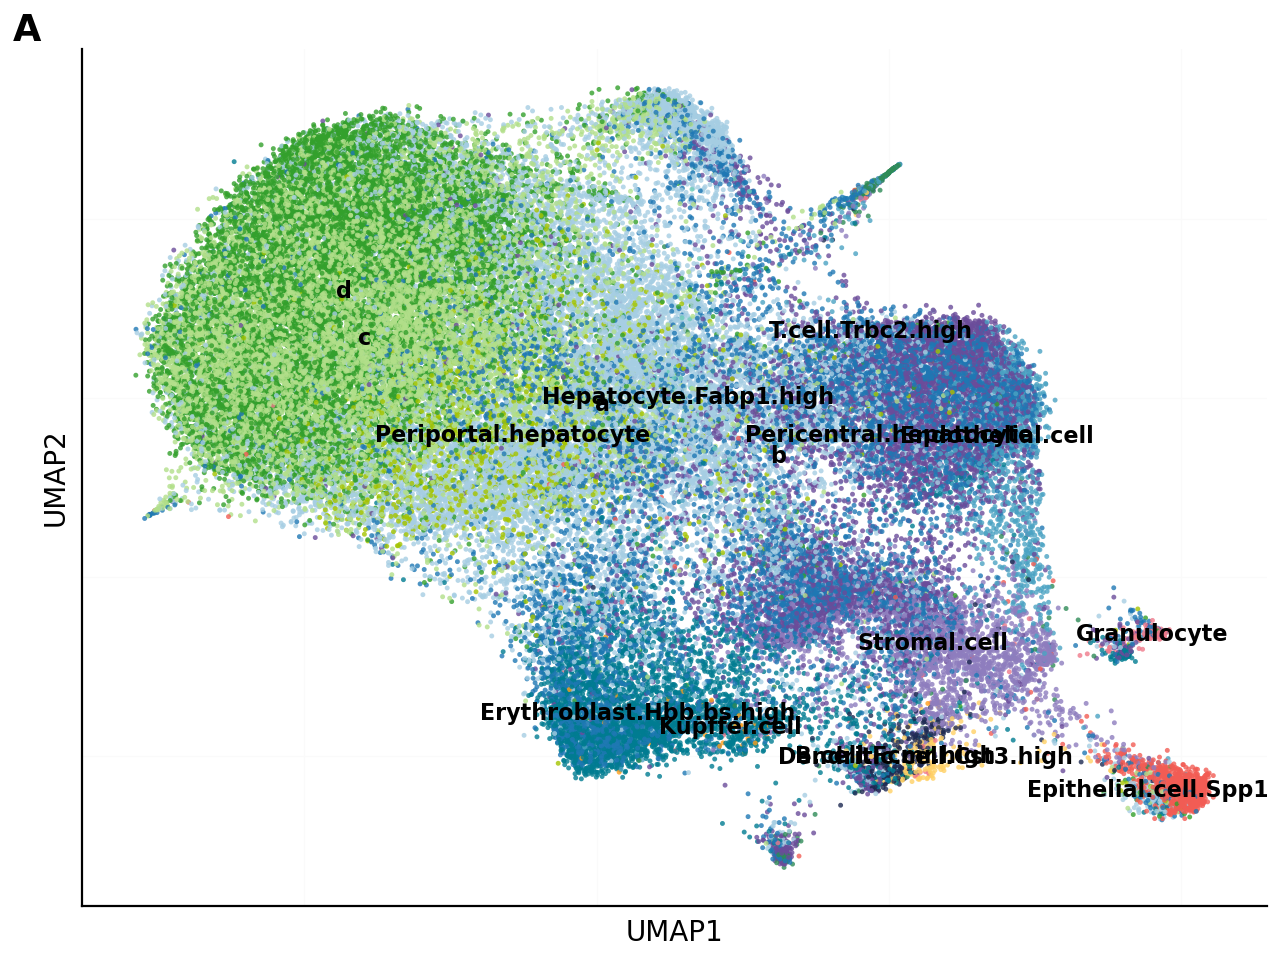

In [66]:
label_positions = (
    data.groupby("original", observed=True)[["umap_1", "umap_2"]].median().reset_index()
)

plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="original"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + geom_text(
        label_positions,
        aes("umap_1", "umap_2", label="original"),
        size=8,
        fontweight="bold",
        color="black",
    )
    + scale_fill_manual(values=custom_colors_xl[: data["original"].nunique()])
    + labs(tag="A", x="UMAP1", y="UMAP2")
    + guides(fill="none")
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
    )
)

plot.save("output/parts/ct_annotation_original.svg", dpi=300)
plot

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/ct_annotation_celltypist.svg


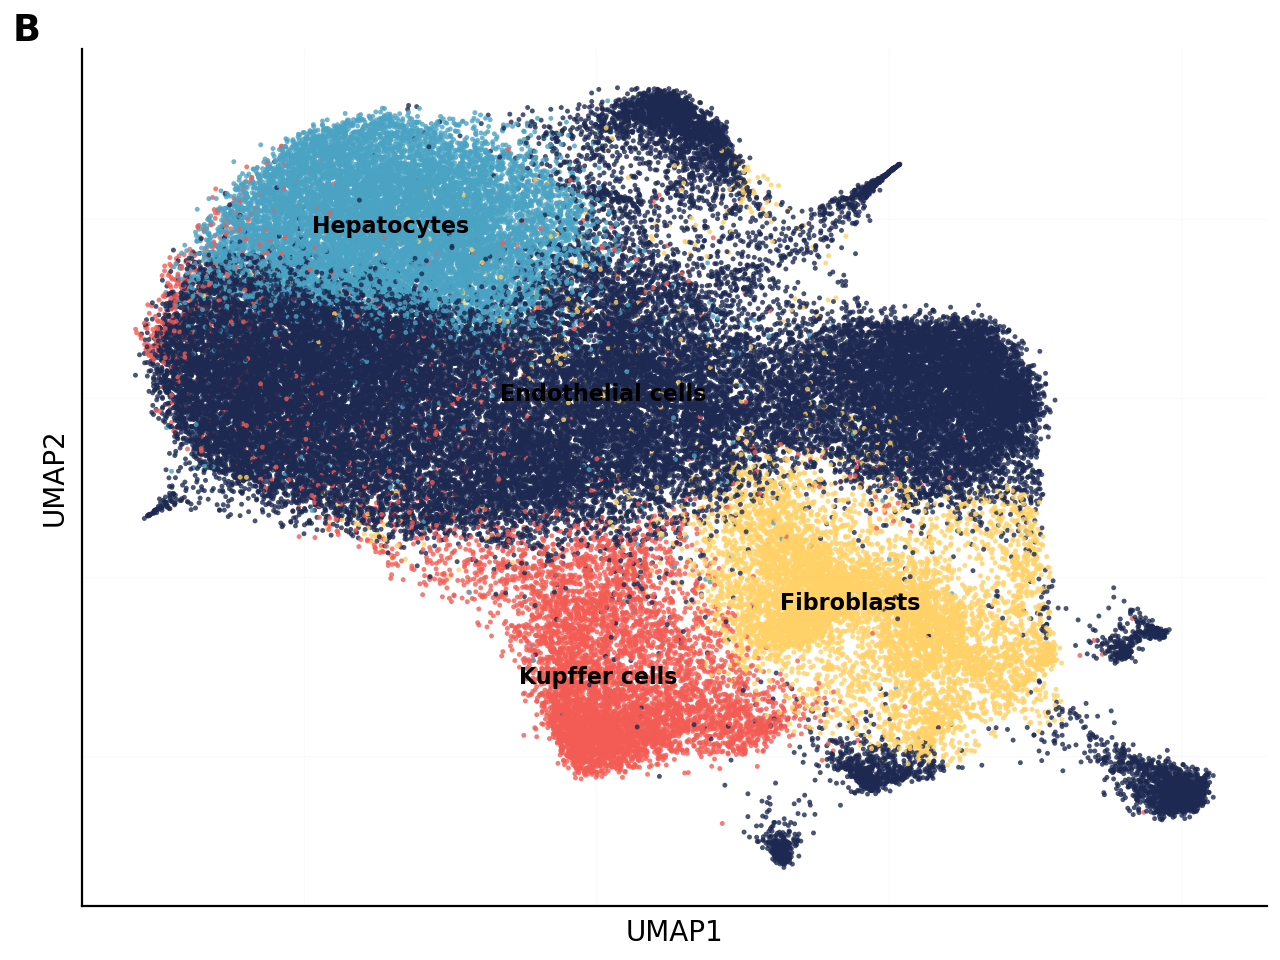

In [88]:
label_positions = (
    data.groupby("celltypist", observed=True)[["umap_1", "umap_2"]]
    .median()
    .reset_index()
)

plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="celltypist"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + geom_text(
        label_positions,
        aes("umap_1", "umap_2", label="celltypist"),
        size=8,
        fontweight="bold",
        color="black",
    )
    + scale_fill_manual(values=custom_colors_xl[: data["celltypist"].nunique()])
    + labs(tag="B", x="UMAP1", y="UMAP2")
    + guides(fill="none")
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
    )
)

plot.save("output/parts/ct_annotation_celltypist.svg", dpi=300)
plot

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/ct_annotation_panglaodb.svg


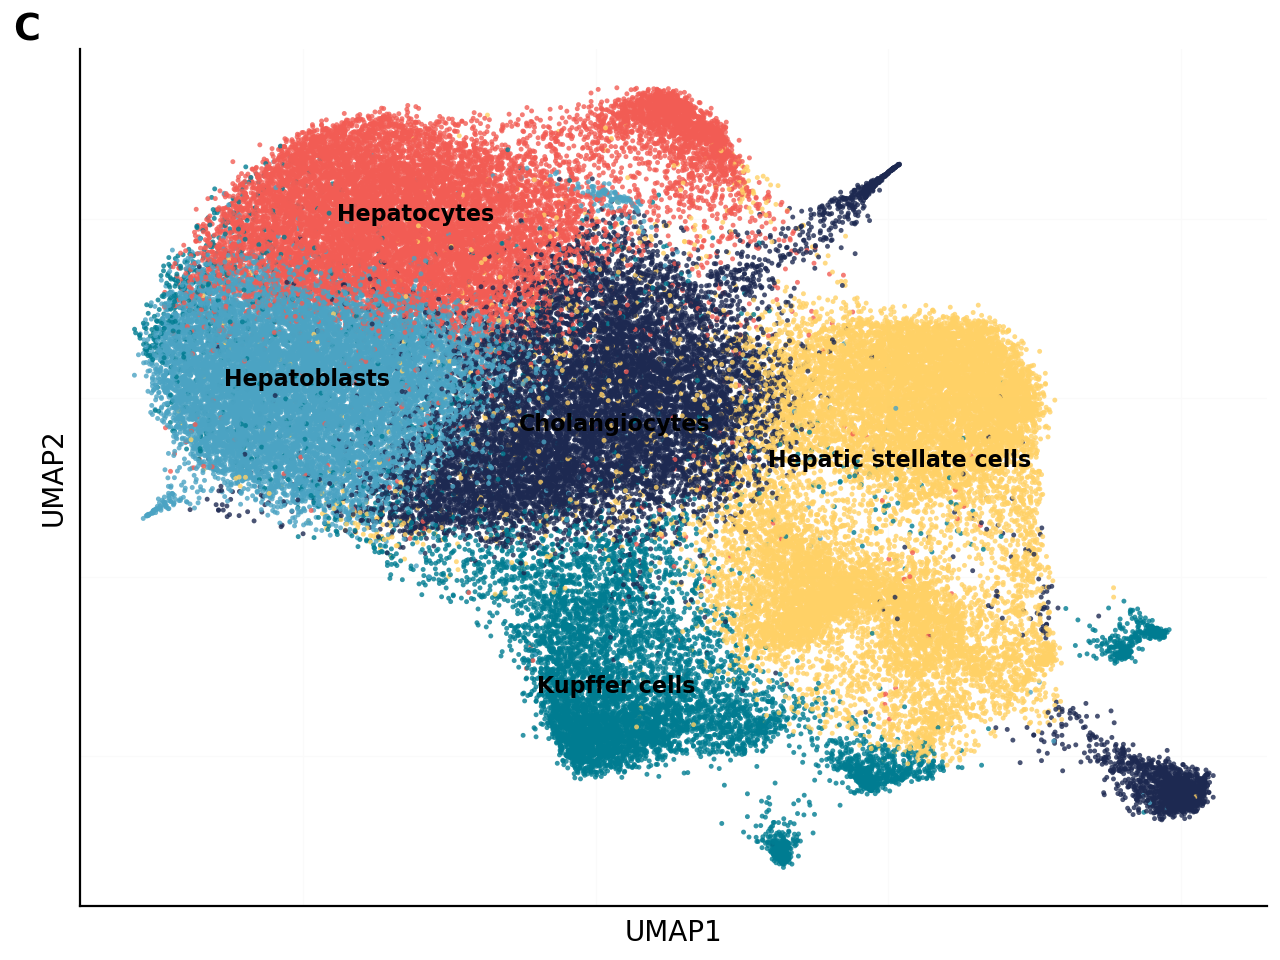

In [91]:
label_positions = (
    data.groupby("panglaodb", observed=True)[["umap_1", "umap_2"]]
    .median()
    .reset_index()
)

plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="panglaodb"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + geom_text(
        label_positions,
        aes("umap_1", "umap_2", label="panglaodb"),
        size=8,
        fontweight="bold",
        color="black",
    )
    + scale_fill_manual(values=custom_colors_xl[: data["panglaodb"].nunique()])
    + labs(tag="C", x="UMAP1", y="UMAP2")
    + guides(fill="none")
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
    )
)

plot.save("output/parts/ct_annotation_panglaodb.svg", dpi=300)
plot

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/ct_annotation_manualt30.svg


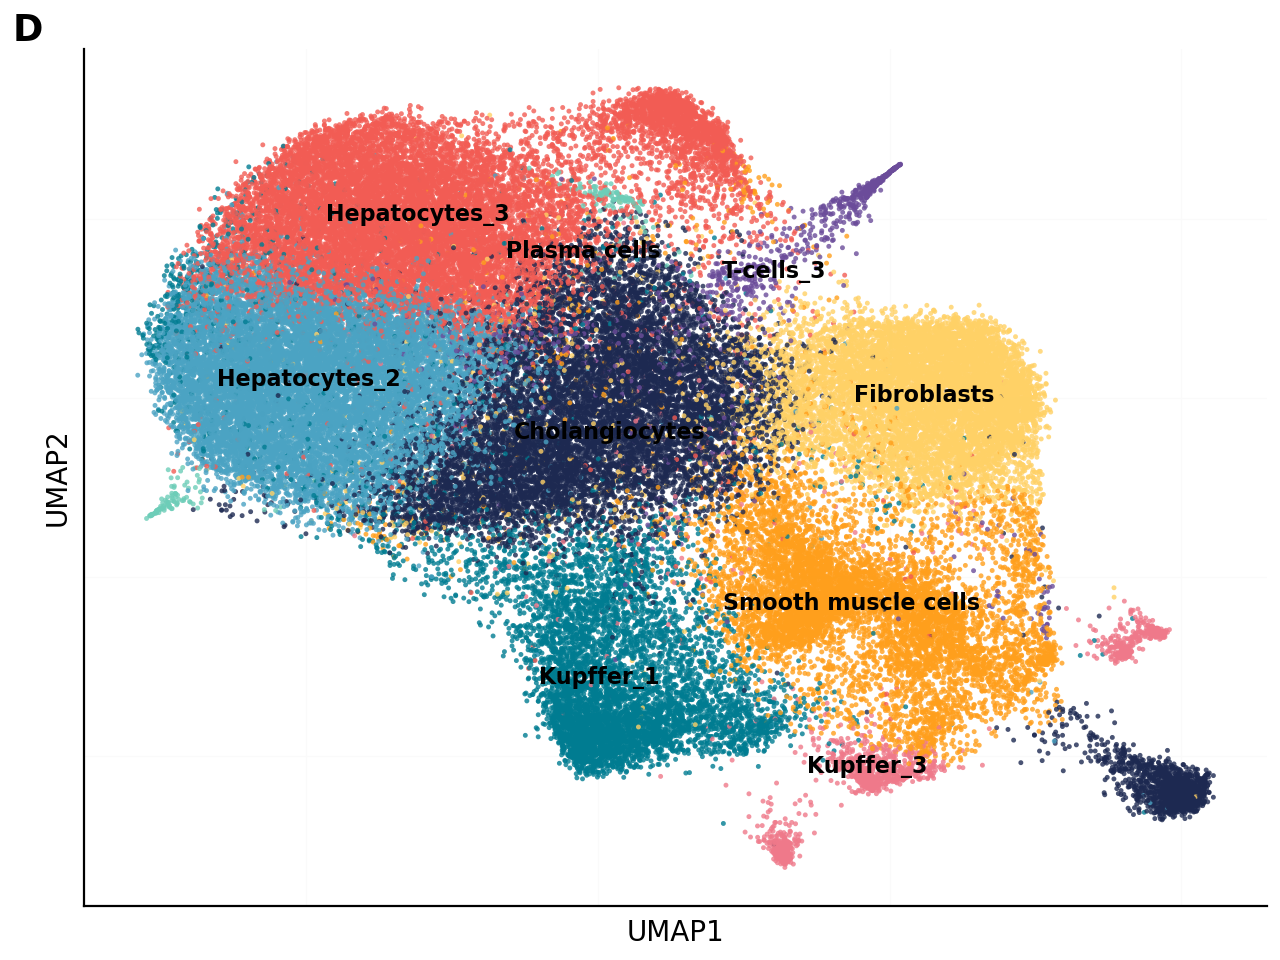

In [90]:
label_positions = (
    data.groupby("manual_t30", observed=True)[["umap_1", "umap_2"]]
    .median()
    .reset_index()
)

plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="manual_t30"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + geom_text(
        label_positions,
        aes("umap_1", "umap_2", label="manual_t30"),
        size=8,
        fontweight="bold",
        color="black",
    )
    + scale_fill_manual(values=custom_colors_xl[: data["manual_t30"].nunique()])
    + labs(tag="D", x="UMAP1", y="UMAP2")
    + guides(fill="none")
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
    )
)

plot.save("output/parts/ct_annotation_manualt30.svg", dpi=300)
plot

## CellTypist Confidence

In [53]:
data = pd.read_feather("data/pdata_CT_predictions.feather")
data["CT_predictions"] = data["CT_predictions"].replace(
    {"Monocytes & Monocyte-derived cells": "Monocytes &\n Monocyte-derived cells"}
)

data.head()

/tmp/ipykernel_182987/3102366080.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


,CT_predictions,CT_majority,confidence,confidence_rounded
liver1_3_1,Hepatocytes,Endothelial cells,0.591862,0.59
liver1_4_1,Endothelial cells,Hepatocytes,0.913311,0.91
liver1_5_1,Hepatocytes,Hepatocytes,0.608518,0.61
liver1_7_1,Fibroblasts,Fibroblasts,0.977266,0.98
liver1_8_1,Endothelial cells,Endothelial cells,0.031366,0.03


In [54]:
data.CT_predictions.unique()

['Hepatocytes', 'Endothelial cells', 'Fibroblasts', 'Kupffer cells', 'Monocytes &\n Monocyte-derived cells', ..., 'NK cells', 'cDC2s', 'B cells', 'cDC1s', 'Mig. cDCs']
Length: 17
Categories (17, object): ['B cells', 'Basophils', 'Cholangiocytes', 'Endothelial cells', ..., 'T cells', 'cDC1s', 'cDC2s', 'pDCs']

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/density_CT_confidence.svg


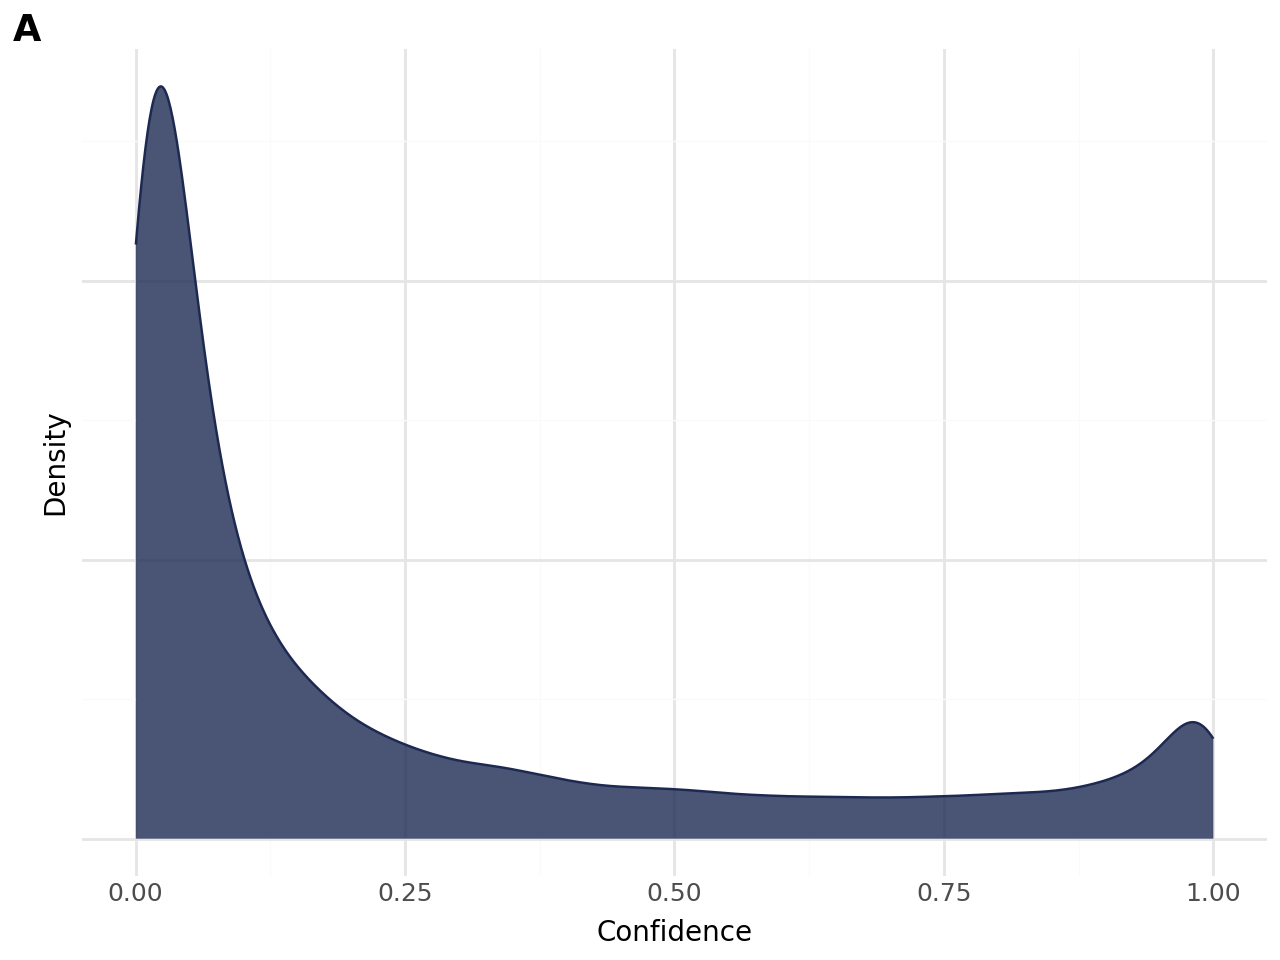

In [55]:
plot = (
    ggplot(data, aes(x="confidence"))
    + geom_density(alpha=0.8, color="#1D2951", fill="#1D2951")
    + labs(
        tag="A",
        x="Confidence",
        y="Density",
    )
    + figure_theme
    + theme(axis_text_y=element_blank())
)

plot.save("output/parts/density_CT_confidence.svg", dpi=300)
plot

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/density_CT_cell_type_confidence.svg


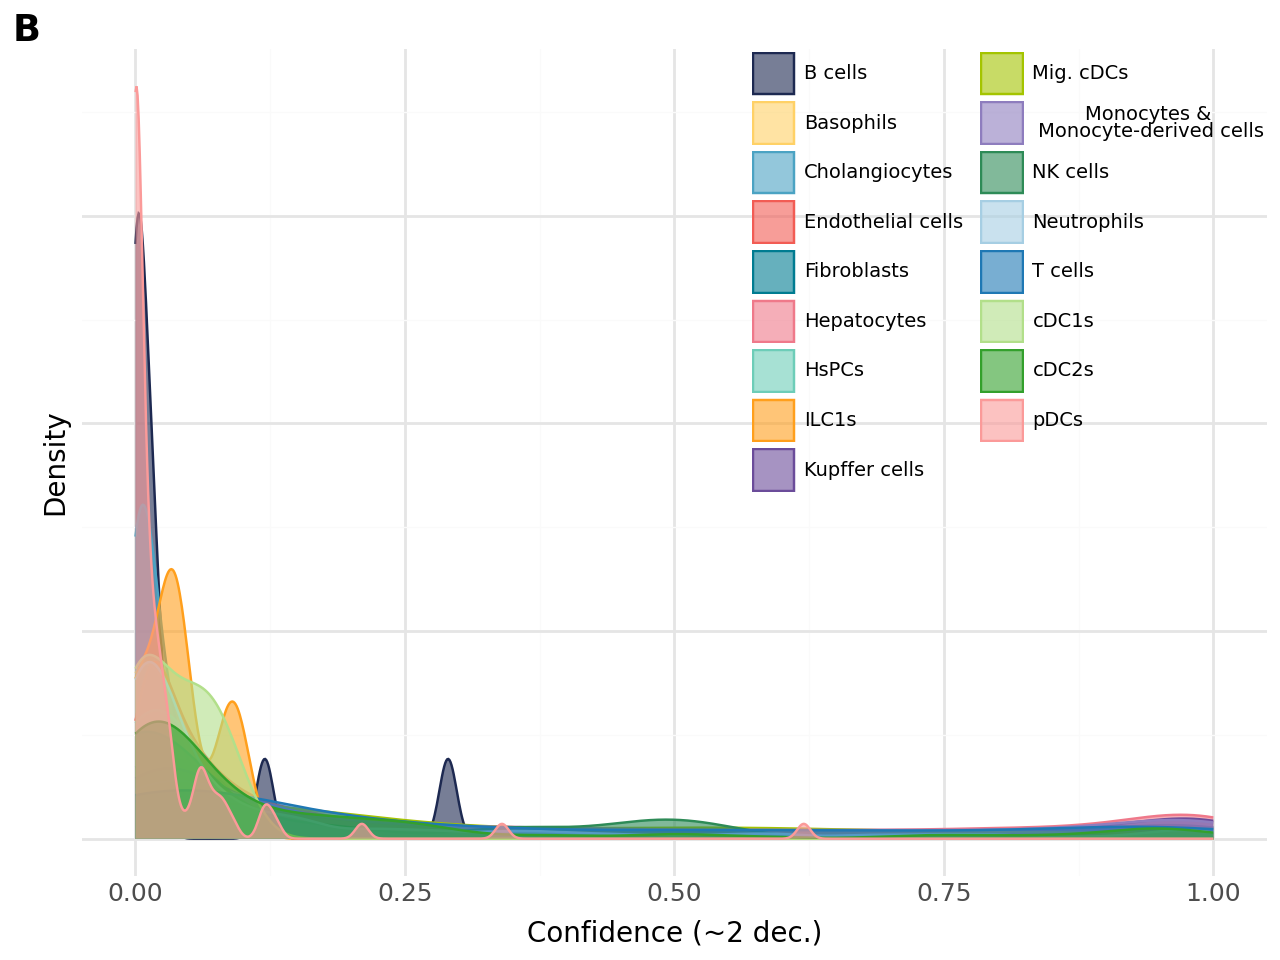

In [57]:
plot = (
    ggplot(
        data, aes(x="confidence_rounded", color="CT_predictions", fill="CT_predictions")
    )
    + geom_density(alpha=0.6)
    + scale_color_manual(values=custom_colors_xl[: data["CT_predictions"].nunique()])
    + scale_fill_manual(values=custom_colors_xl[: data["CT_predictions"].nunique()])
    + labs(
        tag="B",
        x="Confidence (~2 dec.)",
        y="Density",
        fill="",
        color="",
    )
    + figure_theme
    + theme(
        axis_text_y=element_blank(),
        legend_position=(1, 1),
        legend_justification=(1, 1),
        legend_text=element_text(size=7),
    )
)

plot.save("output/parts/density_CT_cell_type_confidence.svg", dpi=300)
plot

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/boxplot_CT_confidence.svg


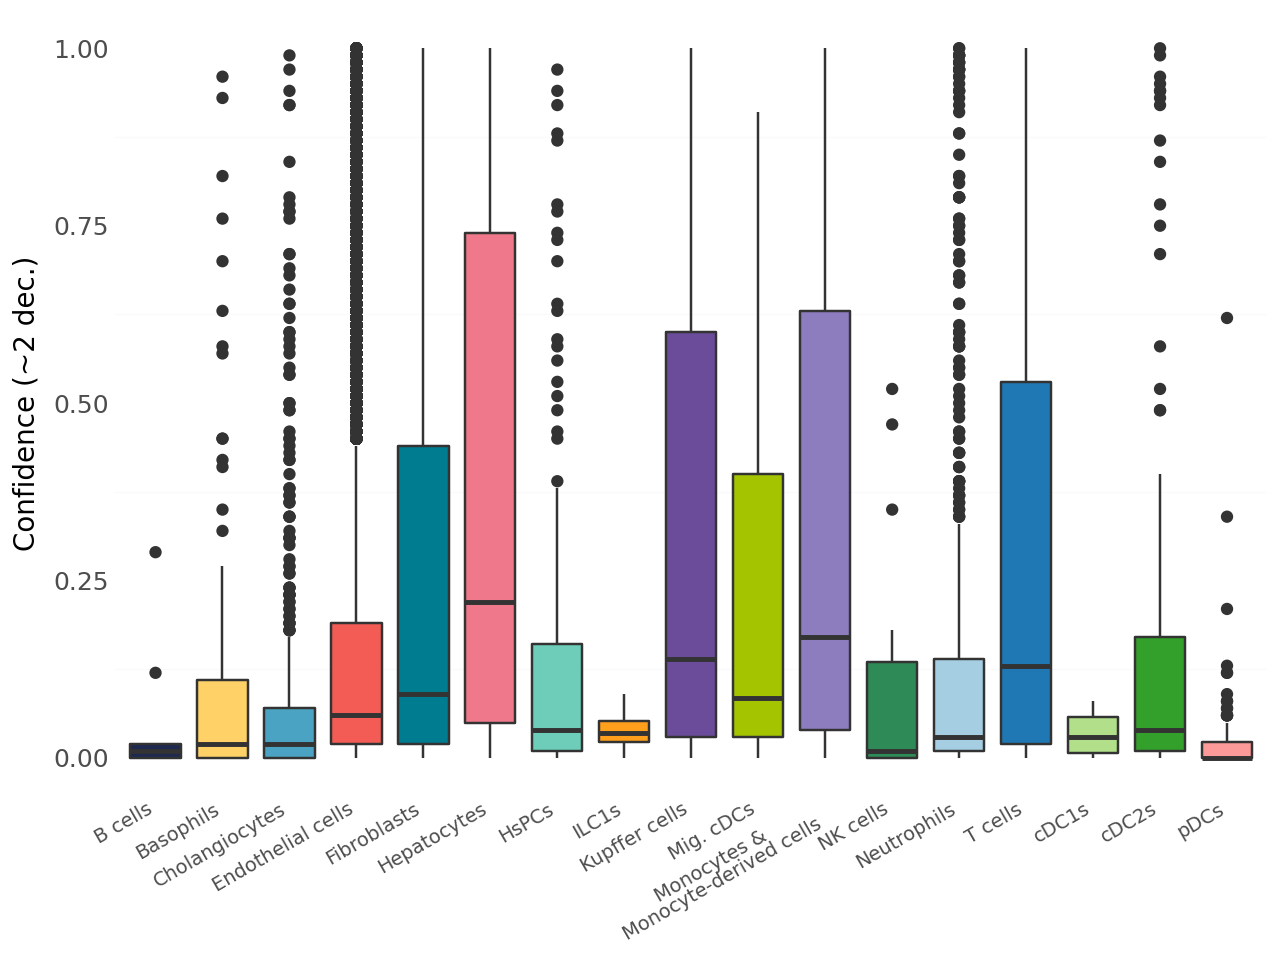

In [59]:
plot = (
    ggplot(data, aes(x="CT_predictions", y="confidence_rounded", fill="CT_predictions"))
    + geom_boxplot(position="dodge")
    + scale_fill_manual(values=custom_colors_xl[: data["CT_predictions"].nunique()])
    + labs(x="", y="Confidence (~2 dec.)")
    + guides(fill="none")
    + figure_theme
    + theme(
        panel_grid_major=element_blank(),
        axis_text_x=element_text(rotation=30, ha="right", size=7),
    )
)

plot.save("output/parts/boxplot_CT_confidence.svg", dpi=300)
plot